# Caso D — Classroom IAQ / Ocupación con sensórica ambiental

Este notebook trabaja con el dataset **In-Gauge / En-Gage** de PhysioNet para entrenar modelos de Machine Learning que predicen la variable **`Occupied`** en aulas.

El enfoque de este desarrollo es deliberadamente más restrictivo que una versión con contexto docente:

- **Sí se usan** variables que pueden obtenerse mediante sensórica ambiental del aula: CO₂, temperatura, humedad y ruido.
- **No se usan** variables de calendario, horario o planificación docente como `Day`, `Hour`, `SchoolDay`, `LessonNumber` o `LessonPct` que pueden dar contexto de que hay clases, pero en base a planificación docente / instituto.
- **No se usan** variables de estado operativo como `CoolingState` y `HeatingState` en el modelo principal, para mantener un MVP basado solo en señales ambientales directas.

La justificación de esta decisión se basa en que variables como hora, día escolar o número de lección pueden ser muy predictivas, pero introducen una forma de **fuga de contexto** o dependencia del calendario. El objetivo del caso es demostrar si la ocupación puede inferirse a partir de señales físicas medibles por sensores, sin depender de horarios lectivos ni planificación externa.

El EDA sí incluye gráficos con variables de contexto docente para evidenciar que son predictivas y justificar por qué se descartan del modelo final.

In [ ]:
# =========================
# 1. Imports y configuración
# =========================

from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import ParameterGrid
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

RANDOM_STATE = 42

# =========================
# Google Drive
# =========================

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# Ruta en Google Drive:
# Mi unidad / simarro-cursoia / caso-d-classrooms
if IN_COLAB:
    DATA_DIR = Path("/content/drive/MyDrive/simarro-cursoia/caso-d-classrooms")
else:
    # Ruta alternativa por si se ejecuta fuera de Colab
    DATA_DIR = Path("G:/Mi unidad/simarro-cursoia/caso-d-classrooms")

# Carpeta de salida dentro de Drive
OUTPUT_DIR = DATA_DIR / "outputs_ingauge_engage_sensorica"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"DATA_DIR: {DATA_DIR.resolve()}")
print(f"OUTPUT_DIR: {OUTPUT_DIR.resolve()}")

if not DATA_DIR.exists():
    raise FileNotFoundError(f"No existe la carpeta de datos: {DATA_DIR}")

Mounted at /content/drive
DATA_DIR: /content/drive/MyDrive/simarro-cursoia/caso-d-classrooms
OUTPUT_DIR: /content/drive/MyDrive/simarro-cursoia/caso-d-classrooms/outputs_ingauge_engage_sensorica


## 2. Carga de datos

El dataset descargado contiene 16 ficheros CSV, cada uno correspondiente a un aula.

Durante la carga se añade una columna `classroom_id` con el nombre del fichero para poder analizar diferencias entre aulas.

In [ ]:
# =========================
# 2. Carga de los CSV desde Google Drive
# =========================

CSV_FILES = [
    "19.csv", "20.csv", "27.csv", "28.csv", "29.csv", "30.csv", "31.csv",
    "40.csv", "41.csv", "43.csv",
    "KB1.csv", "KB2.csv", "KB3.csv", "KB4.csv", "KB5.csv", "KB6.csv",
]

def load_classroom_csvs(data_dir: Path, csv_files: list[str]) -> pd.DataFrame:
    frames = []
    missing_files = []

    for filename in csv_files:
        path = data_dir / filename

        if not path.exists():
            missing_files.append(str(path))
            continue

        df_i = pd.read_csv(path)
        df_i["classroom_id"] = path.stem
        frames.append(df_i)

    if missing_files:
        raise FileNotFoundError(
            "Faltan los siguientes CSV en Google Drive:\n"
            + "\n".join(missing_files)
        )

    df_all = pd.concat(frames, ignore_index=True)
    return df_all

df = load_classroom_csvs(DATA_DIR, CSV_FILES)

print("Dimensiones del dataset unificado:", df.shape)
print("Aulas cargadas:", sorted(df["classroom_id"].unique()))

df.head()

Dimensiones del dataset unificado: (778752, 24)
Aulas cargadas: ['19', '20', '27', '28', '29', '30', '31', '40', '41', '43', 'KB1', 'KB2', 'KB3', 'KB4', 'KB5', 'KB6']


,Time,Day,Occupied,SchoolDay,Hour,LessonNumber,LessonPct,IndoorTemperature,IndoorHumidity,IndoorCO2,IndoorNoise,OutdoorTemperature,OutdoorHumidity,OutdoorDewpoint,OutdoorWindDirection,OutdoorWindSpeed,OutdoorGustSpeed,Precipitation,UvLevel,SolarRadiation,CoolingState,HeatingState,UsabilityMask,classroom_id
0,00:00:00,1,0,1,0,-1,-1.0000,18.9000,58.0000,519.0000,35.0000,13.2500,81.5000,10.0850,135.0000,1.2000,1.6500,0.0000,0.0000,0.0000,0,0,False,19
1,00:05:00,1,0,0,0,-1,-1.0000,18.9000,58.0000,515.0000,35.0000,13.2200,81.5000,10.1400,135.0000,1.1000,1.6000,0.0000,0.0000,0.0000,0,0,False,19
2,00:10:00,1,0,0,0,-1,-1.0000,18.8000,58.0000,519.0000,35.0000,13.2200,82.5000,10.2800,135.0000,1.2000,1.7000,0.0000,0.0000,0.0000,0,0,False,19
3,00:15:00,1,0,0,0,-1,-1.0000,18.8000,58.0000,526.0000,35.0000,13.2200,83.0000,10.4150,135.0000,1.2000,1.7000,0.0000,0.0000,0.0000,0,0,False,19
4,00:20:00,1,0,0,0,-1,-1.0000,18.8000,58.0000,515.0000,35.0000,13.1950,84.0000,10.5250,180.0000,1.1000,1.6000,0.0000,0.0000,0.0000,0,0,False,19


## 3. Limpieza y preparación básica

Se realizan los siguientes pasos de limpieza:

- Conversión de campos booleanos a enteros cuando es necesario.
- Creación de un identificador temporal relativo `time_index` a partir de `Day` y `Hour`.
- Revisión de nulos y duplicados.
- Filtrado opcional de registros usables con `UsabilityMask == True`, que ya es una etiqueta y separación de origen del dataset para filtrar datos útiles.

La columna `Time` es hora anonimizada, por lo que no se convierte a fecha real. Para validación temporal se usa la columna `Day`, que representa el avance del tiempo dentro de cada aula.

In [ ]:
# =========================
# 3. Limpieza básica
# =========================

df = df.copy()

# Normalizar booleanos
if "UsabilityMask" in df.columns:
    df["UsabilityMask"] = df["UsabilityMask"].astype(bool)

# Índice temporal relativo: cada día tiene 24 horas; Hour está en 0-23
df["time_index"] = (df["Day"] - df["Day"].min()) * 24 + df["Hour"]

# Asegurar target binario numérico
df["Occupied"] = df["Occupied"].astype(int)

print("Tipos de datos:")
display(df.dtypes.to_frame("dtype"))

print("Nulos por columna:")
display(df.isna().sum().to_frame("n_missing").sort_values("n_missing", ascending=False))

print("Filas duplicadas:", df.duplicated().sum())

print("Distribución de UsabilityMask:")
display(df["UsabilityMask"].value_counts(dropna=False).to_frame("count"))

# Dataset de modelado: solo datos marcados como usables
df_usable = df[df["UsabilityMask"] == True].copy()
print("Dimensiones usando solo UsabilityMask=True:", df_usable.shape)

df_usable.head()

Tipos de datos:


,dtype
Time,object
Day,int64
Occupied,int64
SchoolDay,int64
Hour,int64
LessonNumber,int64
LessonPct,float64
IndoorTemperature,float64
IndoorHumidity,float64
IndoorCO2,float64


Nulos por columna:


,n_missing
Time,0
Day,0
Occupied,0
SchoolDay,0
Hour,0
LessonNumber,0
LessonPct,0
IndoorTemperature,0
IndoorHumidity,0
IndoorCO2,0


Filas duplicadas: 0
Distribución de UsabilityMask:


,count
UsabilityMask,
False,470304
True,308448


Dimensiones usando solo UsabilityMask=True: (308448, 25)


,Time,Day,Occupied,SchoolDay,Hour,LessonNumber,LessonPct,IndoorTemperature,IndoorHumidity,IndoorCO2,IndoorNoise,OutdoorTemperature,OutdoorHumidity,OutdoorDewpoint,OutdoorWindDirection,OutdoorWindSpeed,OutdoorGustSpeed,Precipitation,UvLevel,SolarRadiation,CoolingState,HeatingState,UsabilityMask,classroom_id,time_index
38592,00:00:00,135,0,1,0,-1,-1.0000,24.2000,60.0000,469.0000,35.0000,17.8300,89.0000,16.1700,202.5000,2.7000,3.1000,0.0000,0.0000,0.0000,0,0,True,19,3216
38593,00:05:00,135,0,1,0,-1,-1.0000,24.1000,60.0000,457.0000,35.0000,17.7800,90.0000,16.2200,202.5000,3.3000,3.8000,0.0000,0.0000,0.0000,0,0,True,19,3216
38594,00:10:00,135,0,1,0,-1,-1.0000,24.0000,60.0000,457.0000,35.0000,17.7800,90.0000,16.1700,180.0000,3.2000,3.6000,0.0000,0.0000,0.0000,0,0,True,19,3216
38595,00:15:00,135,0,1,0,-1,-1.0000,24.0000,60.0000,457.0000,35.0000,17.7200,90.0000,16.1100,180.0000,3.4000,4.0000,0.0000,0.0000,0.0000,0,0,True,19,3216
38596,00:20:00,135,0,1,0,-1,-1.0000,23.9000,60.0000,454.0000,36.0000,17.7200,90.0000,16.1100,202.5000,3.1000,3.7000,0.0000,0.0000,0.0000,0,0,True,19,3216


## 4. EDA y justificación de variables

El análisis exploratorio se divide en dos partes:

1. **EDA general y ambiental**, centrado en la variable objetivo y en sensores interiores.
2. **EDA de variables de contexto docente**, usado únicamente para justificar su exclusión del entrenamiento.

Las variables de contexto pueden explicar ocupación porque representan el calendario de clases, pero no son señales ambientales obtenidas por sensórica. Por eso se analizan, pero no se usan como predictores del modelo final.

In [ ]:
# =========================
# 4.1 Resumen general
# =========================

print("Columnas:")
print(df_usable.columns.tolist())

print("Dimensiones:", df_usable.shape)

print("Rango de Day:", df_usable["Day"].min(), "-", df_usable["Day"].max())

print("Aulas:", df_usable["classroom_id"].nunique())

display(df_usable.describe(include="all").T)

Columnas:
['Time', 'Day', 'Occupied', 'SchoolDay', 'Hour', 'LessonNumber', 'LessonPct', 'IndoorTemperature', 'IndoorHumidity', 'IndoorCO2', 'IndoorNoise', 'OutdoorTemperature', 'OutdoorHumidity', 'OutdoorDewpoint', 'OutdoorWindDirection', 'OutdoorWindSpeed', 'OutdoorGustSpeed', 'Precipitation', 'UvLevel', 'SolarRadiation', 'CoolingState', 'HeatingState', 'UsabilityMask', 'classroom_id', 'time_index']
Dimensiones: (308448, 25)
Rango de Day: 2 - 169
Aulas: 16


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Time,308448,288,22:35:00,1071,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day,308448.0000,NaN,NaN,NaN,84.5500,60.1923,2.0000,31.0000,60.0000,147.0000,169.0000
Occupied,308448.0000,NaN,NaN,NaN,0.1507,0.3578,0.0000,0.0000,0.0000,0.0000,1.0000
SchoolDay,308448.0000,NaN,NaN,NaN,0.7134,0.4522,0.0000,0.0000,1.0000,1.0000,1.0000
Hour,308448.0000,NaN,NaN,NaN,11.5000,6.9222,0.0000,5.7500,11.5000,17.2500,23.0000
LessonNumber,308448.0000,NaN,NaN,NaN,-0.0224,2.5828,-1.0000,-1.0000,-1.0000,-1.0000,9.0000
LessonPct,308448.0000,NaN,NaN,NaN,-0.7843,0.5279,-1.0000,-1.0000,-1.0000,-1.0000,1.8750
IndoorTemperature,308448.0000,NaN,NaN,NaN,19.6412,3.5316,8.6000,17.1000,19.6000,22.1000,39.7000
IndoorHumidity,308448.0000,NaN,NaN,NaN,56.4434,6.0925,30.0000,53.0000,57.0000,60.0000,79.0000
IndoorCO2,308448.0000,NaN,NaN,NaN,795.9772,711.0821,146.0000,456.0000,550.0000,784.0000,5000.0000


,count,percentage
Occupied,,
0,261956,84.9271
1,46492,15.0729


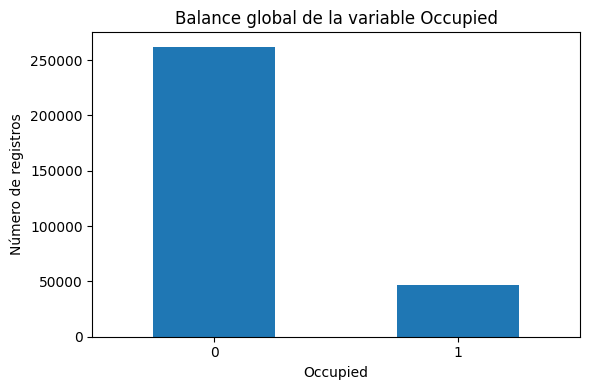

In [ ]:
# =========================
# 4.2 Balance global de ocupación
# =========================

class_counts = df_usable["Occupied"].value_counts().sort_index()
class_pct = df_usable["Occupied"].value_counts(normalize=True).sort_index() * 100
class_balance = pd.DataFrame({"count": class_counts, "percentage": class_pct})

display(class_balance)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Balance global de la variable Occupied")
plt.xlabel("Occupied")
plt.ylabel("Número de registros")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,classroom_id,Occupied,count,percentage
0,19,0,8258,84.3342
1,19,1,1534,15.6658
2,20,0,7555,84.6214
3,20,1,1373,15.3786
4,27,0,4856,88.7427
5,27,1,616,11.2573
6,28,0,20506,82.7923
7,28,1,4262,17.2077
8,29,0,23208,85.7270
9,29,1,3864,14.2730


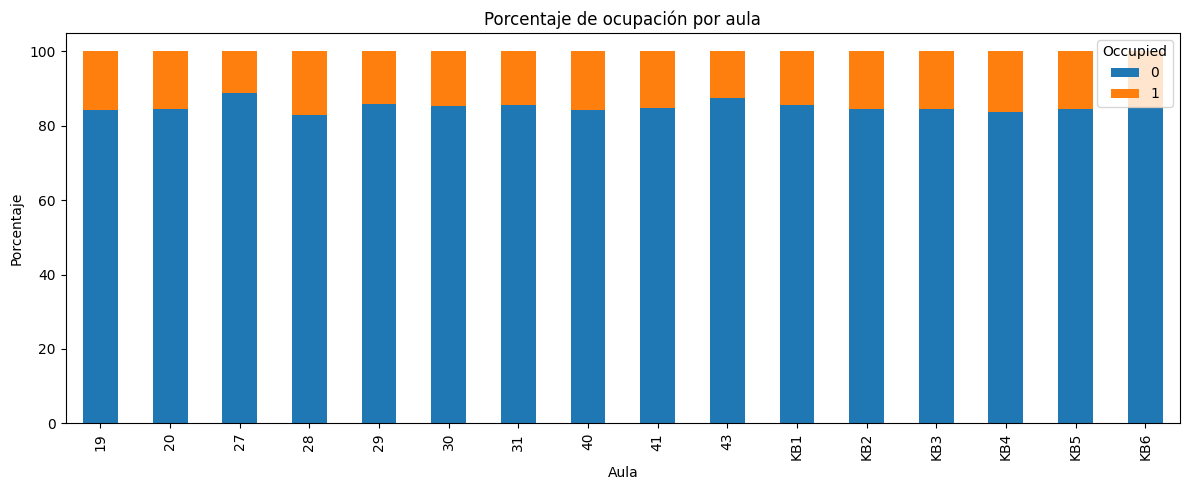

In [ ]:
# =========================
# 4.3 Balance por aula
# =========================

balance_by_classroom = (
    df_usable.groupby(["classroom_id", "Occupied"])
    .size()
    .reset_index(name="count")
)
balance_by_classroom["percentage"] = (
    balance_by_classroom["count"]
    / balance_by_classroom.groupby("classroom_id")["count"].transform("sum")
    * 100
)

display(balance_by_classroom)

pivot_balance = balance_by_classroom.pivot(
    index="classroom_id", columns="Occupied", values="percentage"
).fillna(0)

pivot_balance.plot(kind="bar", stacked=True, figsize=(12, 5))
plt.title("Porcentaje de ocupación por aula")
plt.xlabel("Aula")
plt.ylabel("Porcentaje")
plt.legend(title="Occupied")
plt.tight_layout()
plt.show()

IndoorTemperature                               IndoorHumidity  \
                      mean  median    std    min     max           mean   
Occupied                                                                  
0                  19.4302 19.3000 3.6019 8.6000 39.7000        56.2833   
1                  20.8304 20.9000 2.8250 9.8000 34.5000        57.3452   

                                        IndoorCO2                      \
          median    std     min     max      mean    median       std   
Occupied                                                                
0        57.0000 6.0183 30.0000 76.0000  671.9790  519.0000  520.1544   
1        57.0000 6.4208 31.0000 79.0000 1494.6364 1072.0000 1120.4591   

                            IndoorNoise                                  
              min       max        mean  median     std     min     max  
Occupied                                                                 
0        227.0000 5000.0000     39.0725 36.0000  6.5009 35.0000 81.0000  
1        146.0000 5000.0000     56.5728 56.0000 10.3997 35.0000 86.0000

<Figure size 700x400 with 0 Axes>

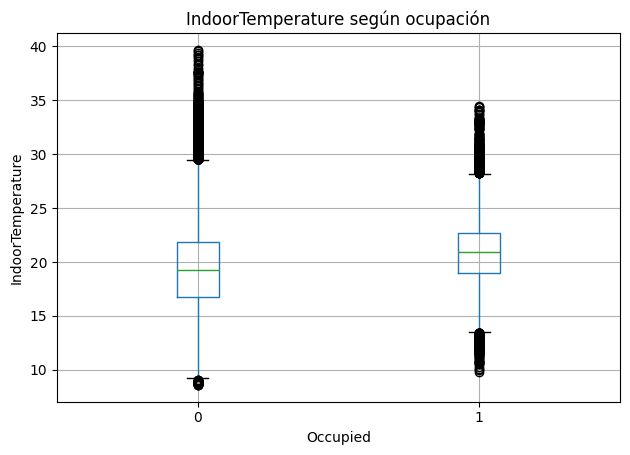

<Figure size 700x400 with 0 Axes>

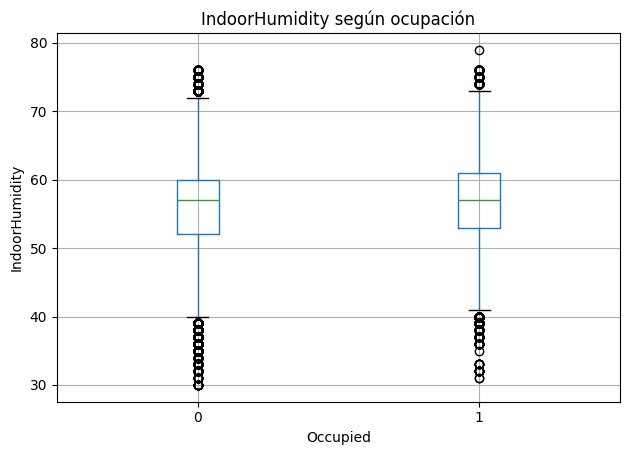

<Figure size 700x400 with 0 Axes>

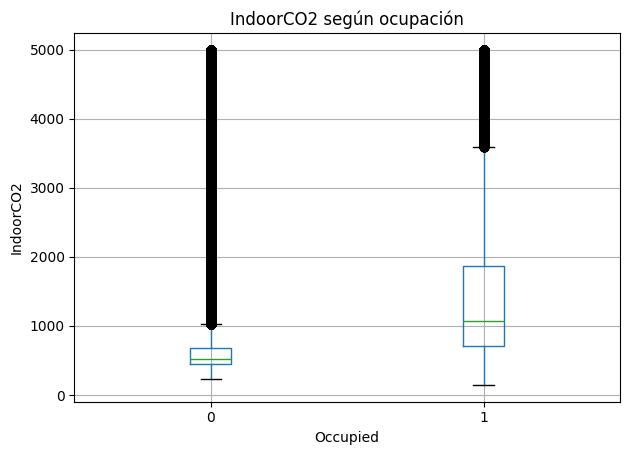

<Figure size 700x400 with 0 Axes>

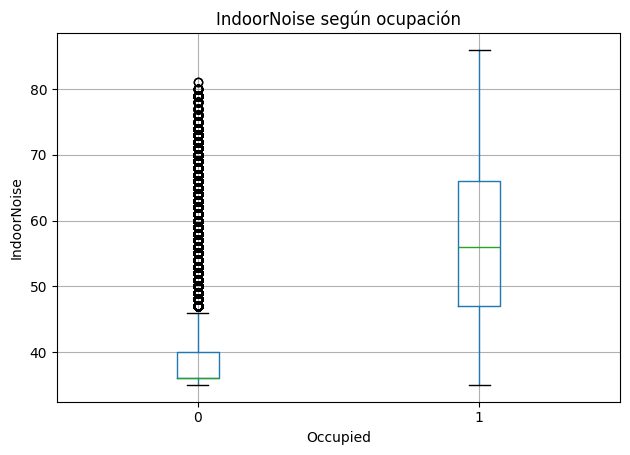

In [ ]:
# =========================
# 4.4 Variables interiores según ocupación
# =========================

indoor_features = [
    "IndoorTemperature",
    "IndoorHumidity",
    "IndoorCO2",
    "IndoorNoise",
]

summary_by_target = df_usable.groupby("Occupied")[indoor_features].agg(["mean", "median", "std", "min", "max"])
display(summary_by_target)

for col in indoor_features:
    plt.figure(figsize=(7, 4))
    df_usable.boxplot(column=col, by="Occupied")
    plt.title(f"{col} según ocupación")
    plt.suptitle("")
    plt.xlabel("Occupied")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

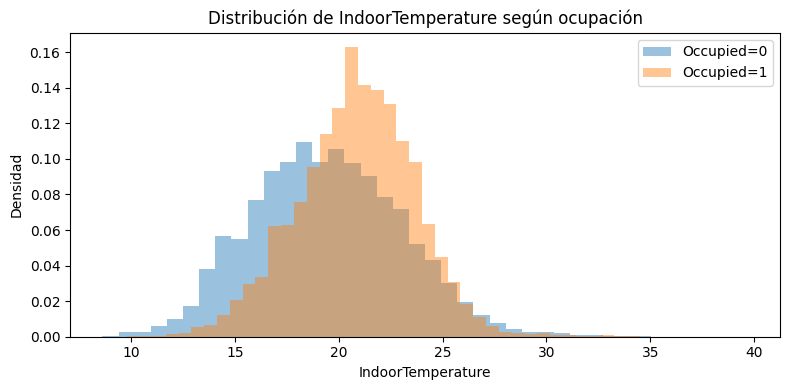

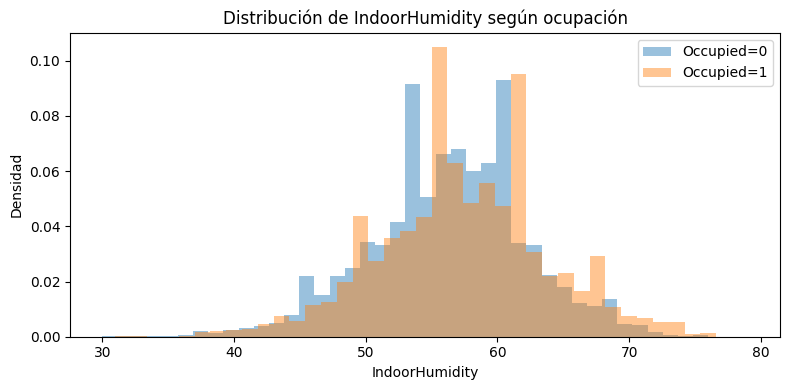

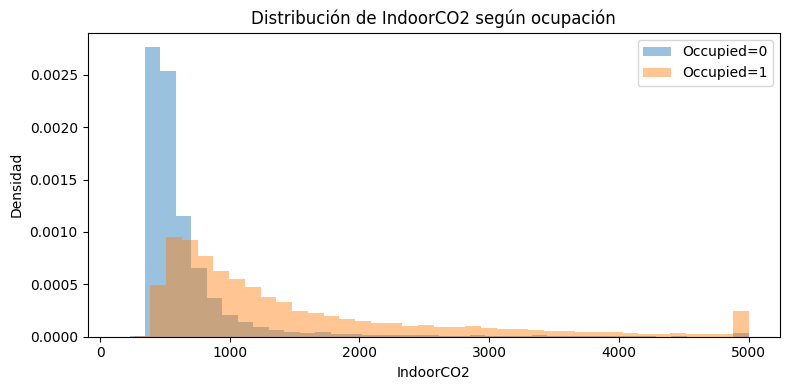

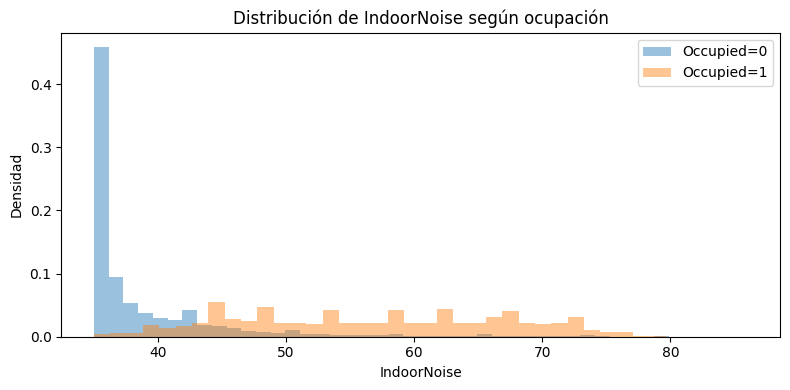

In [ ]:
# =========================
# 4.5 Distribución de variables ambientales por ocupación
# =========================

sensor_features = [
    "IndoorTemperature",
    "IndoorHumidity",
    "IndoorCO2",
    "IndoorNoise",
]

for col in sensor_features:
    plt.figure(figsize=(8, 4))
    for occupied_value in sorted(df_usable["Occupied"].unique()):
        subset = df_usable.loc[df_usable["Occupied"] == occupied_value, col].dropna()
        subset.plot(kind="hist", bins=40, alpha=0.45, density=True, label=f"Occupied={occupied_value}")
    plt.title(f"Distribución de {col} según ocupación")
    plt.xlabel(col)
    plt.ylabel("Densidad")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 4.6 EDA de contexto docente: variables predictivas, pero no desplegables como sensórica

En este bloque se muestran variables que suelen tener capacidad predictiva:

- `Hour`: la ocupación aumenta en franjas lectivas y cae fuera de horario.
- `SchoolDay`: diferencia días escolares de no escolares.
- `LessonNumber` y `LessonPct`: reflejan el calendario interno de clases.
- `Day` o un día relativo derivado pueden capturar patrones semanales o de calendario.

Estas variables son útiles para entender el dataset, pero **no se incorporan al entrenamiento** porque el objetivo del caso es detectar ocupación a partir de señales físicas del aula, no de una agenda docente conocida previamente.

,Hour,mean_occupied,count
0,0,0.0000,12852
1,1,0.0000,12852
2,2,0.0000,12852
3,3,0.0000,12852
4,4,0.0000,12852
5,5,0.0000,12852
6,6,0.0000,12852
7,7,0.0000,12852
8,8,0.1186,12852
9,9,0.4756,12852


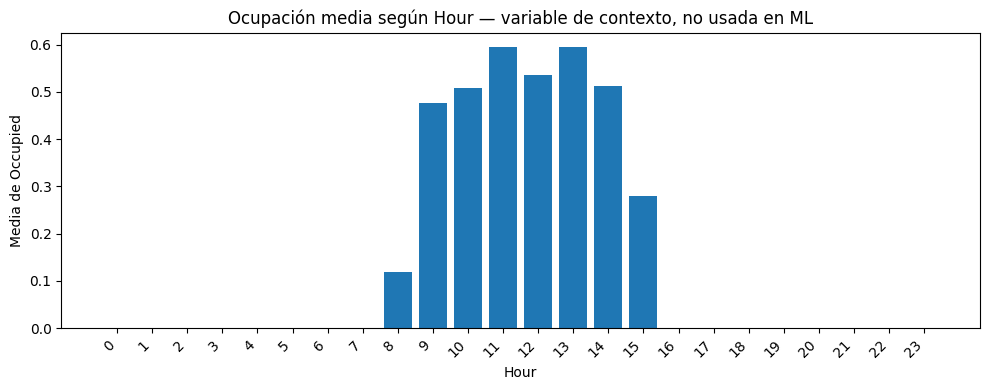

,SchoolDay,mean_occupied,count
0,0,0.0000,88416
1,1,0.2113,220032


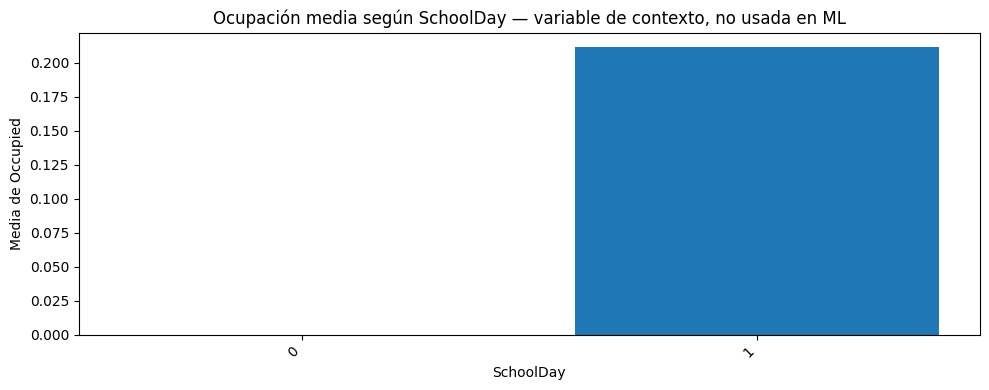

,LessonNumber,mean_occupied,count
0,-1,0.0000,261956
1,0,1.0000,1524
2,1,1.0000,4008
3,2,1.0000,4208
4,3,1.0000,5001
5,4,1.0000,3320
6,5,1.0000,3312
7,6,1.0000,5418
8,7,1.0000,3968
9,8,1.0000,4104


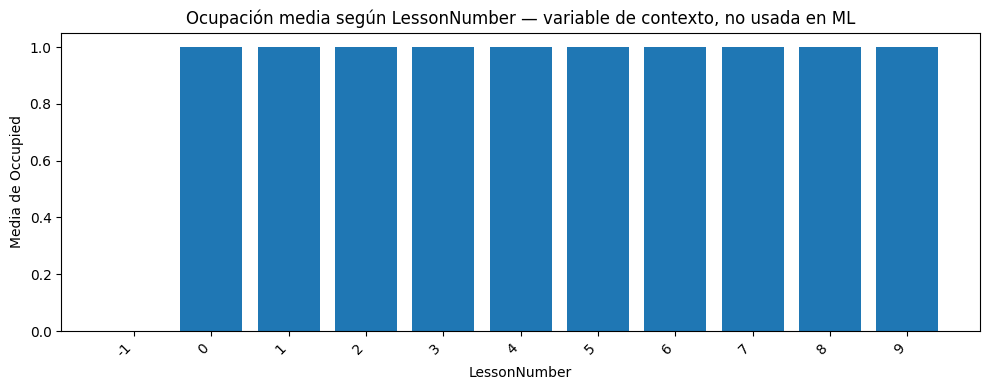

,relative_weekday,mean_occupied,count
0,0,0.2228,46368
1,1,0.2141,48672
2,2,0.2157,42624
3,3,0.2048,42048
4,4,0.0000,42624
5,5,0.0000,45792
6,6,0.1969,40320


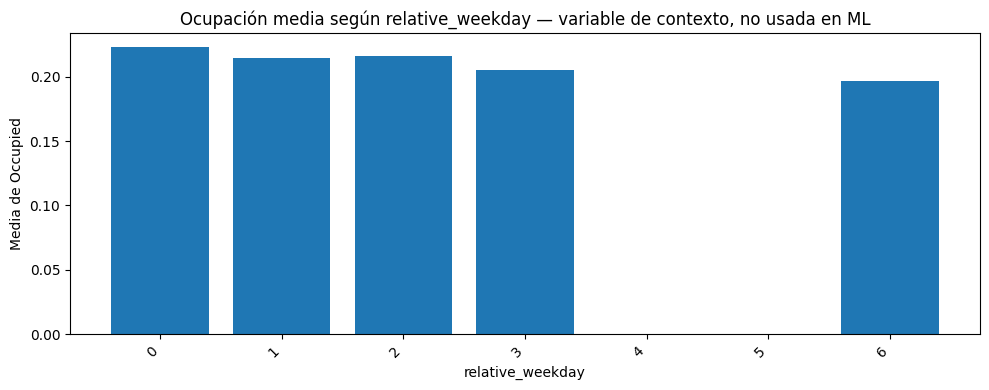

In [ ]:
# =========================
# 4.6.1 Ocupación media por variables de contexto docente
# =========================

# Día relativo de la semana: aproximación basada en Day anonimizado.
# Se usa solo para EDA, no para modelado.
df_usable["relative_weekday"] = ((df_usable["Day"] - df_usable["Day"].min()) % 7).astype(int)

context_candidates = [
    "Hour",
    "SchoolDay",
    "LessonNumber",
    "relative_weekday",
]

for col in context_candidates:
    if col not in df_usable.columns:
        continue

    tmp = (
        df_usable.groupby(col)["Occupied"]
        .agg(mean_occupied="mean", count="size")
        .reset_index()
        .sort_values(col)
    )

    display(tmp)

    plt.figure(figsize=(10, 4))
    plt.bar(tmp[col].astype(str), tmp["mean_occupied"])
    plt.title(f"Ocupación media según {col} — variable de contexto, no usada en ML")
    plt.xlabel(col)
    plt.ylabel("Media de Occupied")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

,LessonPct_bin,mean_occupied,count
0,0,1.0000,6079
1,0-25%,1.0000,11673
2,25-50%,1.0000,12707
3,50-75%,1.0000,9075
4,75-100%,1.0000,5775


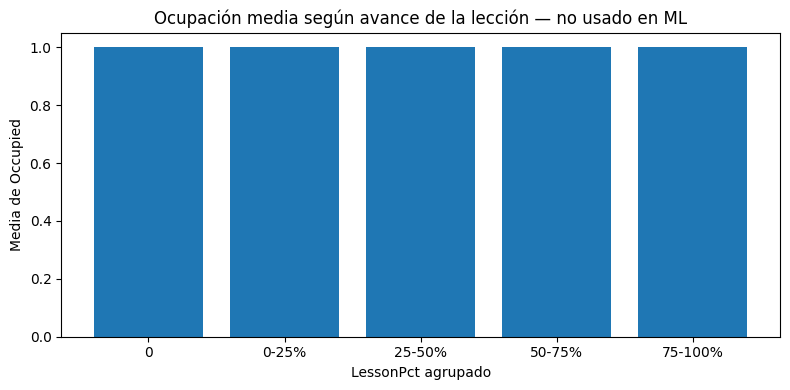

In [ ]:
# =========================
# 4.6.2 Ocupación media según LessonPct
# =========================

if "LessonPct" in df_usable.columns:
    lesson_pct_df = df_usable[["LessonPct", "Occupied"]].dropna().copy()
    lesson_pct_df["LessonPct_bin"] = pd.cut(
        lesson_pct_df["LessonPct"],
        bins=[-0.01, 0.0, 0.25, 0.50, 0.75, 1.0],
        labels=["0", "0-25%", "25-50%", "50-75%", "75-100%"],
        include_lowest=True,
    )

    occ_by_lesson_pct = (
        lesson_pct_df.groupby("LessonPct_bin", observed=False)["Occupied"]
        .agg(mean_occupied="mean", count="size")
        .reset_index()
    )

    display(occ_by_lesson_pct)

    plt.figure(figsize=(8, 4))
    plt.bar(occ_by_lesson_pct["LessonPct_bin"].astype(str), occ_by_lesson_pct["mean_occupied"])
    plt.title("Ocupación media según avance de la lección — no usado en ML")
    plt.xlabel("LessonPct agrupado")
    plt.ylabel("Media de Occupied")
    plt.tight_layout()
    plt.show()

Hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
SchoolDay,,,,,,,,,,,,,,,,,,,,,,,,
0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1660,0.6670,0.7110,0.8340,0.7490,0.8330,0.7190,0.3920,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


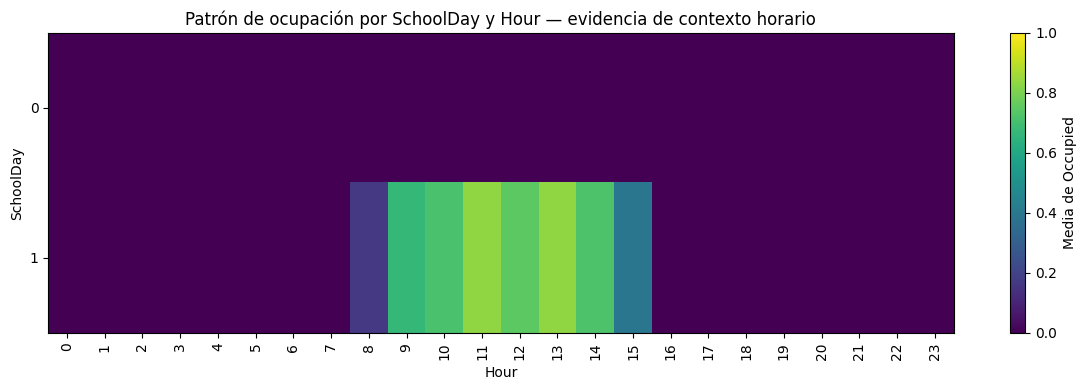

In [ ]:
# =========================
# 4.6.3 Mapa horario: SchoolDay x Hour
# =========================

if {"SchoolDay", "Hour", "Occupied"}.issubset(df_usable.columns):
    heatmap_data = df_usable.pivot_table(
        index="SchoolDay",
        columns="Hour",
        values="Occupied",
        aggfunc="mean",
    )

    display(heatmap_data.round(3))

    plt.figure(figsize=(12, 4))
    plt.imshow(heatmap_data, aspect="auto", vmin=0, vmax=1)
    plt.colorbar(label="Media de Occupied")
    plt.title("Patrón de ocupación por SchoolDay y Hour — evidencia de contexto horario")
    plt.xlabel("Hour")
    plt.ylabel("SchoolDay")
    plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=90)
    plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
    plt.tight_layout()
    plt.show()

,correlation_with_occupied,grupo
LessonPct,0.9699,contexto_docente_no_usado_en_modelo
LessonNumber,0.8984,contexto_docente_no_usado_en_modelo
IndoorNoise,0.6549,sensorica_ambiental_usada_en_modelo
IndoorCO2,0.4139,sensorica_ambiental_usada_en_modelo
SchoolDay,0.2671,contexto_docente_no_usado_en_modelo
relative_weekday,-0.1518,contexto_docente_no_usado_en_modelo
CoolingState,0.1484,contexto_docente_no_usado_en_modelo
IndoorTemperature,0.1419,sensorica_ambiental_usada_en_modelo
HeatingState,0.0727,contexto_docente_no_usado_en_modelo
IndoorHumidity,0.0624,sensorica_ambiental_usada_en_modelo


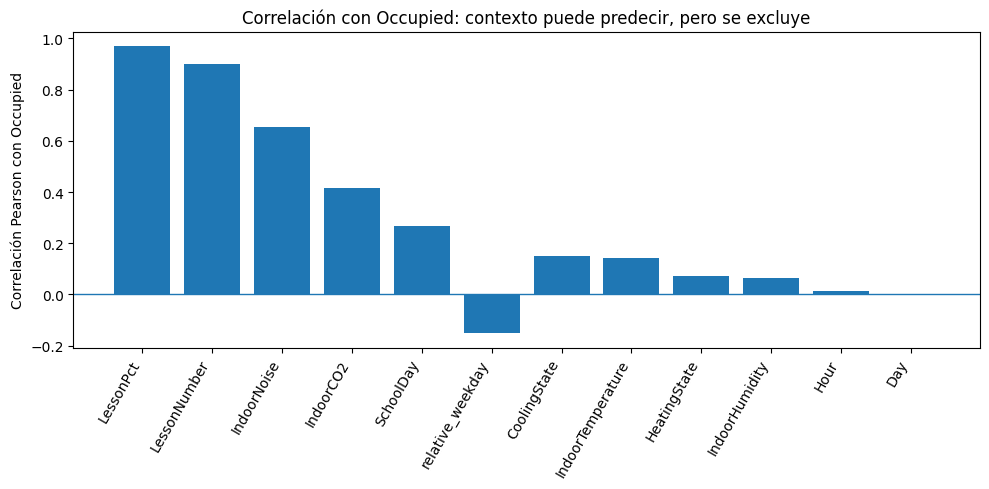

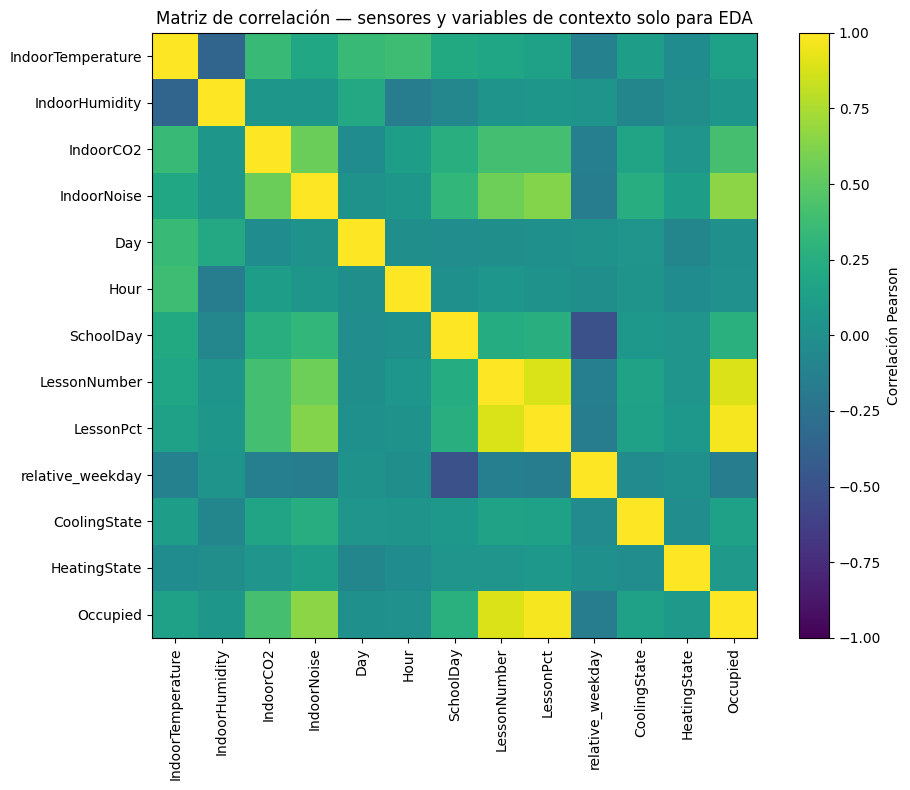

In [ ]:
# =========================
# 4.7 Correlación con Occupied: sensores vs contexto
# =========================

sensor_features = [
    "IndoorTemperature",
    "IndoorHumidity",
    "IndoorCO2",
    "IndoorNoise",
]

context_features_for_eda = [
    "Day",
    "Hour",
    "SchoolDay",
    "LessonNumber",
    "LessonPct",
    "relative_weekday",
    "CoolingState",
    "HeatingState",
]

available_corr_cols = [
    c for c in sensor_features + context_features_for_eda + ["Occupied"]
    if c in df_usable.columns and pd.api.types.is_numeric_dtype(df_usable[c])
]

corr_matrix = df_usable[available_corr_cols].corr()

corr_with_target = (
    corr_matrix["Occupied"]
    .drop("Occupied")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("correlation_with_occupied")
)

def feature_group(feature: str) -> str:
    if feature in sensor_features:
        return "sensorica_ambiental_usada_en_modelo"
    return "contexto_docente_no_usado_en_modelo"

corr_with_target["grupo"] = corr_with_target.index.map(feature_group)
display(corr_with_target)

plt.figure(figsize=(10, 5))
plt.bar(corr_with_target.index, corr_with_target["correlation_with_occupied"])
plt.axhline(0, linewidth=1)
plt.title("Correlación con Occupied: contexto puede predecir, pero se excluye")
plt.ylabel("Correlación Pearson con Occupied")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, vmin=-1, vmax=1)
plt.colorbar(label="Correlación Pearson")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Matriz de correlación — sensores y variables de contexto solo para EDA")
plt.tight_layout()
plt.show()

## 5. Preparación para Machine Learning

A partir de aquí se descarta completamente el enfoque con contexto docente.

El modelo final usa solo variables ambientales interiores:

- `IndoorTemperature`
- `IndoorHumidity`
- `IndoorCO2`
- `IndoorNoise`

Se excluyen explícitamente:

- `Day`, `Hour`, `relative_weekday`
- `SchoolDay`, `LessonNumber`, `LessonPct`
- `CoolingState`, `HeatingState`
- `Time`, `classroom_id`, `UsabilityMask`

La evaluación mantiene un **split temporal por aula**: para cada aula, los primeros días se usan para entrenamiento y los últimos días para test. Así se evita entrenar y evaluar mezclando registros muy cercanos temporalmente.

In [ ]:
# =========================
# 5. Split temporal por aula: train / validation / test final
# =========================

TARGET = "Occupied"

SENSOR_FEATURES = [
    "IndoorTemperature",
    "IndoorHumidity",
    "IndoorCO2",
    "IndoorNoise",
]

EXCLUDED_CONTEXT_FEATURES = [
    "Day",
    "Hour",
    "relative_weekday",
    "SchoolDay",
    "LessonNumber",
    "LessonPct",
    "CoolingState",
    "HeatingState",
    "Time",
    "classroom_id",
    "UsabilityMask",
]

print("Variables usadas en el modelo:")
print(SENSOR_FEATURES)

print("\nVariables excluidas por ser contexto/calendario/operación o no ser predictoras de sensórica ambiental directa:")
print([c for c in EXCLUDED_CONTEXT_FEATURES if c in df_usable.columns])

missing_sensor_cols = [c for c in SENSOR_FEATURES if c not in df_usable.columns]
if missing_sensor_cols:
    raise ValueError(f"Faltan variables ambientales esperadas: {missing_sensor_cols}")


def temporal_train_val_test_split_by_classroom(
    data: pd.DataFrame,
    train_ratio: float = 0.60,
    validation_ratio: float = 0.20,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Divide temporalmente cada aula en tres bloques:
    - primeros 60% de días: entrenamiento
    - siguiente 20% de días: validación / selección de modelo e hiperparámetros
    - último 20% de días: test final

    La división se hace por aula para evitar que un aula quede representada solo en una partición.
    No se usa split aleatorio porque los registros tienen estructura temporal.
    """

    train_parts = []
    validation_parts = []
    test_parts = []

    for classroom_id, group in data.groupby("classroom_id"):
        group = group.sort_values(["Day", "Hour", "Time"]).copy()
        unique_days = sorted(group["Day"].unique())
        n_days = len(unique_days)

        if n_days < 3:
            print(
                f"Advertencia: el aula {classroom_id} tiene menos de 3 días "
                "y se excluye del split train/validation/test."
            )
            continue

        train_end = int(n_days * train_ratio)
        validation_end = int(n_days * (train_ratio + validation_ratio))

        # Garantizar al menos un día en cada partición.
        train_end = max(1, train_end)
        validation_end = max(train_end + 1, validation_end)
        validation_end = min(validation_end, n_days - 1)

        if train_end >= validation_end:
            train_end = max(1, validation_end - 1)

        train_days = set(unique_days[:train_end])
        validation_days = set(unique_days[train_end:validation_end])
        test_days = set(unique_days[validation_end:])

        train_parts.append(group[group["Day"].isin(train_days)])
        validation_parts.append(group[group["Day"].isin(validation_days)])
        test_parts.append(group[group["Day"].isin(test_days)])

    if not train_parts or not validation_parts or not test_parts:
        raise ValueError(
            "No se pudo generar el split temporal train/validation/test. "
            "Revisar cantidad de días por aula."
        )

    train_df = pd.concat(train_parts, ignore_index=True)
    validation_df = pd.concat(validation_parts, ignore_index=True)
    test_df = pd.concat(test_parts, ignore_index=True)

    return train_df, validation_df, test_df


train_df, validation_df, test_df = temporal_train_val_test_split_by_classroom(
    df_usable,
    train_ratio=0.60,
    validation_ratio=0.20,
)

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test final:", test_df.shape)

print("\nBalance train:")
display(train_df[TARGET].value_counts(normalize=True).to_frame("proportion"))

print("\nBalance validation:")
display(validation_df[TARGET].value_counts(normalize=True).to_frame("proportion"))

print("\nBalance test final:")
display(test_df[TARGET].value_counts(normalize=True).to_frame("proportion"))

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test_final"],
    "rows": [len(train_df), len(validation_df), len(test_df)],
    "occupied_rate": [
        train_df[TARGET].mean(),
        validation_df[TARGET].mean(),
        test_df[TARGET].mean(),
    ],
    "min_day": [
        train_df["Day"].min(),
        validation_df["Day"].min(),
        test_df["Day"].min(),
    ],
    "max_day": [
        train_df["Day"].max(),
        validation_df["Day"].max(),
        test_df["Day"].max(),
    ],
})

display(split_summary)


Variables usadas en el modelo:
['IndoorTemperature', 'IndoorHumidity', 'IndoorCO2', 'IndoorNoise']

Variables excluidas por ser contexto/calendario/operación o no ser predictoras de sensórica ambiental directa:
['Day', 'Hour', 'relative_weekday', 'SchoolDay', 'LessonNumber', 'LessonPct', 'CoolingState', 'HeatingState', 'Time', 'classroom_id', 'UsabilityMask']
Train: (183168, 26)
Validation: (61632, 26)
Test final: (63648, 26)

Balance train:


,proportion
Occupied,
0,0.8505
1,0.1495



Balance validation:


,proportion
Occupied,
0,0.8441
1,0.1559



Balance test final:


,proportion
Occupied,
0,0.8506
1,0.1494


,split,rows,occupied_rate,min_day,max_day
0,train,183168,0.1495,2,156
1,validation,61632,0.1559,41,162
2,test_final,63648,0.1494,66,169


## 6. Entrenamiento, validación e hiperparametrización

Se usa una estrategia en tres fases:

1. **Entrenamiento:** los modelos se ajustan con el primer 60% temporal de cada aula.
2. **Validación:** se prueban combinaciones de hiperparámetros con el siguiente 20% temporal. Esta partición sirve para seleccionar modelo e hiperparámetros.
3. **Test final:** una vez elegido el mejor modelo por validación, se reentrena cada modelo con `train + validation` y se evalúa una sola vez sobre el último 20% temporal.

Esto evita usar el test final para tomar decisiones de modelado.

In [ ]:
# =========================
# 6. Entrenamiento, validación e hiperparametrización
# =========================

def build_model_search_space() -> dict[str, dict]:
    """
    Define modelos candidatos y sus grillas de hiperparámetros.

    La búsqueda se mantiene acotada para que sea ejecutable en Colab.
    La selección se hace usando la partición de validación temporal,
    no el test final.
    """

    return {
        "Baseline_MostFrequent": {
            "estimator": DummyClassifier(strategy="most_frequent"),
            "params": {},
        },
        "LogisticRegression": {
            "estimator": Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    max_iter=1000,
                    solver="liblinear",
                    random_state=RANDOM_STATE,
                )),
            ]),
            "params": {
                "model__C": [0.01, 0.1, 1.0, 10.0],
                "model__class_weight": [None, "balanced"],
            },
        },
        "GaussianNB": {
            "estimator": Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("model", GaussianNB()),
            ]),
            "params": {
                "model__var_smoothing": [1e-9, 1e-8, 1e-7],
            },
        },
        "DecisionTree": {
            "estimator": Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("model", DecisionTreeClassifier(
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                )),
            ]),
            "params": {
                "model__max_depth": [4, 8, 12, None],
                "model__min_samples_leaf": [20, 50, 100],
            },
        },
        "RandomForest": {
            "estimator": Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("model", RandomForestClassifier(
                    class_weight="balanced_subsample",
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                )),
            ]),
            "params": {
                "model__n_estimators": [100, 200],
                "model__max_depth": [8, 12, None],
                "model__min_samples_leaf": [20, 50],
            },
        },
        "HistGradientBoosting": {
            "estimator": Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("model", HistGradientBoostingClassifier(
                    random_state=RANDOM_STATE,
                )),
            ]),
            "params": {
                "model__max_iter": [100, 200],
                "model__learning_rate": [0.03, 0.07, 0.1],
                "model__max_leaf_nodes": [15, 31],
                "model__l2_regularization": [0.0, 0.1],
            },
        },
    }


def get_positive_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return model.predict(X)


def evaluate_model(model_name: str, model, X, y, feature_set_name: str, split_name: str) -> dict:
    y_pred = model.predict(X)
    y_score = get_positive_scores(model, X)

    if y.nunique() < 2:
        auc = np.nan
    else:
        auc = roc_auc_score(y, y_score)

    return {
        "model": model_name,
        "feature_set": feature_set_name,
        "split": split_name,
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
        "auc_roc": auc,
    }


def train_validate_tune_and_test(feature_columns: list[str], feature_set_name: str):
    X_train = train_df[feature_columns]
    y_train = train_df[TARGET]

    X_validation = validation_df[feature_columns]
    y_validation = validation_df[TARGET]

    X_train_validation = pd.concat([X_train, X_validation], axis=0)
    y_train_validation = pd.concat([y_train, y_validation], axis=0)

    X_test = test_df[feature_columns]
    y_test = test_df[TARGET]

    search_space = build_model_search_space()

    tuning_rows = []
    best_rows = []

    print("=" * 80)
    print("Búsqueda de hiperparámetros sobre VALIDATION")
    print("=" * 80)

    for model_name, config in search_space.items():
        base_estimator = config["estimator"]
        params_grid = list(ParameterGrid(config["params"]))

        if len(params_grid) == 0:
            params_grid = [{}]

        print(f"\nModelo: {model_name} | combinaciones: {len(params_grid)}")

        model_candidate_rows = []

        for candidate_idx, params in enumerate(params_grid, start=1):
            model = clone(base_estimator)
            model.set_params(**params)

            model.fit(X_train, y_train)

            row = evaluate_model(
                model_name=model_name,
                model=model,
                X=X_validation,
                y=y_validation,
                feature_set_name=feature_set_name,
                split_name="validation",
            )

            row["candidate_id"] = candidate_idx
            row["params"] = params
            model_candidate_rows.append(row)
            tuning_rows.append(row)

        model_candidates_df = pd.DataFrame(model_candidate_rows)
        best_candidate = (
            model_candidates_df
            .sort_values(["f1", "auc_roc", "accuracy"], ascending=False, na_position="last")
            .iloc[0]
            .to_dict()
        )
        best_rows.append(best_candidate)

        print(
            f"Mejor {model_name} en validation | "
            f"F1={best_candidate['f1']:.4f} | "
            f"AUC={best_candidate['auc_roc']:.4f} | "
            f"params={best_candidate['params']}"
        )

    tuning_results = pd.DataFrame(tuning_rows)
    model_selection_results = (
        pd.DataFrame(best_rows)
        .sort_values(["f1", "auc_roc", "accuracy"], ascending=False, na_position="last")
        .reset_index(drop=True)
    )

    print("\n" + "=" * 80)
    print("Reentrenamiento con TRAIN + VALIDATION y evaluación en TEST FINAL")
    print("=" * 80)

    fitted_models = {}
    final_rows = []

    for _, selected_row in model_selection_results.iterrows():
        model_name = selected_row["model"]
        best_params = selected_row["params"]

        final_model = clone(search_space[model_name]["estimator"])
        final_model.set_params(**best_params)
        final_model.fit(X_train_validation, y_train_validation)

        fitted_models[model_name] = final_model

        test_row = evaluate_model(
            model_name=model_name,
            model=final_model,
            X=X_test,
            y=y_test,
            feature_set_name=feature_set_name,
            split_name="test_final",
        )

        test_row["selected_validation_f1"] = selected_row["f1"]
        test_row["selected_validation_auc_roc"] = selected_row["auc_roc"]
        test_row["best_params"] = best_params
        final_rows.append(test_row)

    final_results = (
        pd.DataFrame(final_rows)
        .sort_values("selected_validation_f1", ascending=False)
        .reset_index(drop=True)
    )

    return fitted_models, tuning_results, model_selection_results, final_results


fitted_models, tuning_results, model_selection_results, results = train_validate_tune_and_test(
    SENSOR_FEATURES,
    "sensorica_ambiental",
)

print("\nMejores hiperparámetros por modelo según VALIDATION:")
display(model_selection_results[[
    "model", "f1", "auc_roc", "accuracy", "precision", "recall", "params"
]].round(4))

print("\nEvaluación final en TEST FINAL tras reentrenar con TRAIN + VALIDATION:")
display(results[[
    "model",
    "selected_validation_f1",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "auc_roc",
    "best_params",
]].round(4))


Búsqueda de hiperparámetros sobre VALIDATION

Modelo: Baseline_MostFrequent | combinaciones: 1
Mejor Baseline_MostFrequent en validation | F1=0.0000 | AUC=0.5000 | params={}

Modelo: LogisticRegression | combinaciones: 8
Mejor LogisticRegression en validation | F1=0.6913 | AUC=0.9397 | params={'model__C': 10.0, 'model__class_weight': 'balanced'}

Modelo: GaussianNB | combinaciones: 3
Mejor GaussianNB en validation | F1=0.6624 | AUC=0.9351 | params={'model__var_smoothing': 1e-09}

Modelo: DecisionTree | combinaciones: 12
Mejor DecisionTree en validation | F1=0.6528 | AUC=0.9378 | params={'model__max_depth': 4, 'model__min_samples_leaf': 20}

Modelo: RandomForest | combinaciones: 12
Mejor RandomForest en validation | F1=0.6833 | AUC=0.9422 | params={'model__max_depth': None, 'model__min_samples_leaf': 20, 'model__n_estimators': 200}

Modelo: HistGradientBoosting | combinaciones: 24
Mejor HistGradientBoosting en validation | F1=0.6774 | AUC=0.9465 | params={'model__l2_regularization': 0.0

,model,f1,auc_roc,accuracy,precision,recall,params
0,LogisticRegression,0.6913,0.9397,0.8841,0.5912,0.8321,"{'model__C': 10.0, 'model__class_weight': 'bal..."
1,RandomForest,0.6833,0.9422,0.8743,0.5627,0.8696,"{'model__max_depth': None, 'model__min_samples..."
2,HistGradientBoosting,0.6774,0.9465,0.9062,0.7304,0.6316,"{'model__l2_regularization': 0.0, 'model__lear..."
3,GaussianNB,0.6624,0.9351,0.8985,0.6879,0.6387,{'model__var_smoothing': 1e-09}
4,DecisionTree,0.6528,0.9378,0.8488,0.5084,0.9119,"{'model__max_depth': 4, 'model__min_samples_le..."
5,Baseline_MostFrequent,0.0000,0.5000,0.8441,0.0000,0.0000,{}



Evaluación final en TEST FINAL tras reentrenar con TRAIN + VALIDATION:


,model,selected_validation_f1,accuracy,precision,recall,f1,auc_roc,best_params
0,LogisticRegression,0.6913,0.8848,0.5737,0.8911,0.6980,0.9397,"{'model__C': 10.0, 'model__class_weight': 'bal..."
1,RandomForest,0.6833,0.8688,0.5384,0.8546,0.6606,0.9362,"{'model__max_depth': None, 'model__min_samples..."
2,HistGradientBoosting,0.6774,0.8966,0.6647,0.6217,0.6425,0.9410,"{'model__l2_regularization': 0.0, 'model__lear..."
3,GaussianNB,0.6624,0.8913,0.6196,0.7057,0.6599,0.9338,{'model__var_smoothing': 1e-09}
4,DecisionTree,0.6528,0.8544,0.5067,0.9483,0.6605,0.9383,"{'model__max_depth': 4, 'model__min_samples_le..."
5,Baseline_MostFrequent,0.0000,0.8506,0.0000,0.0000,0.0000,0.5000,{}


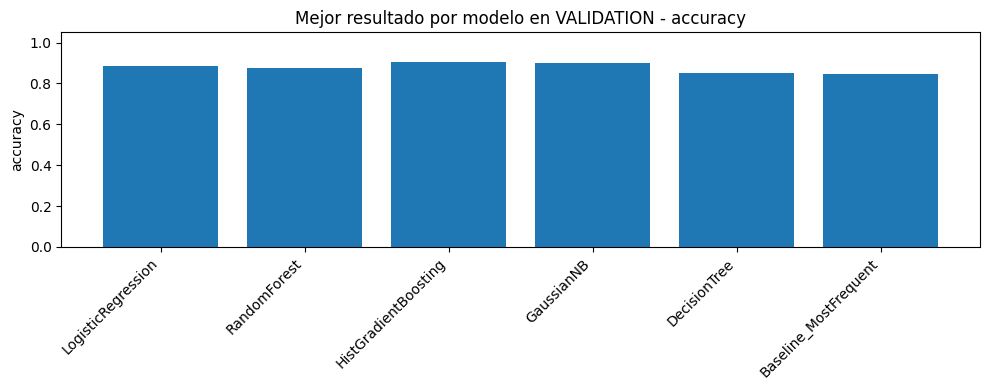

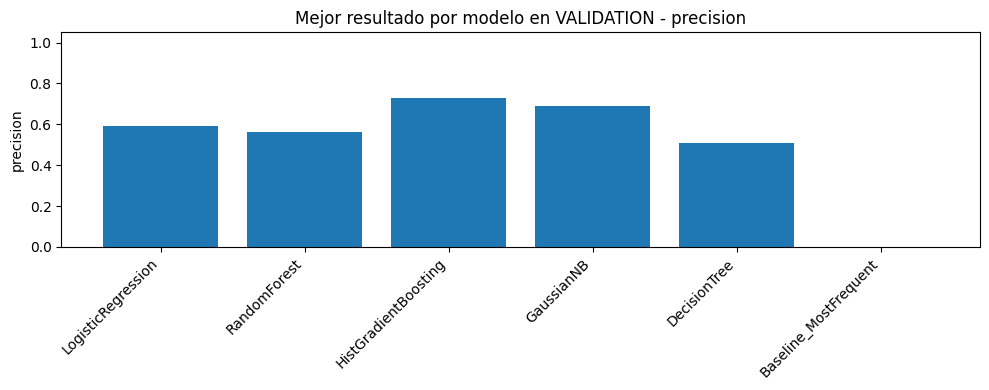

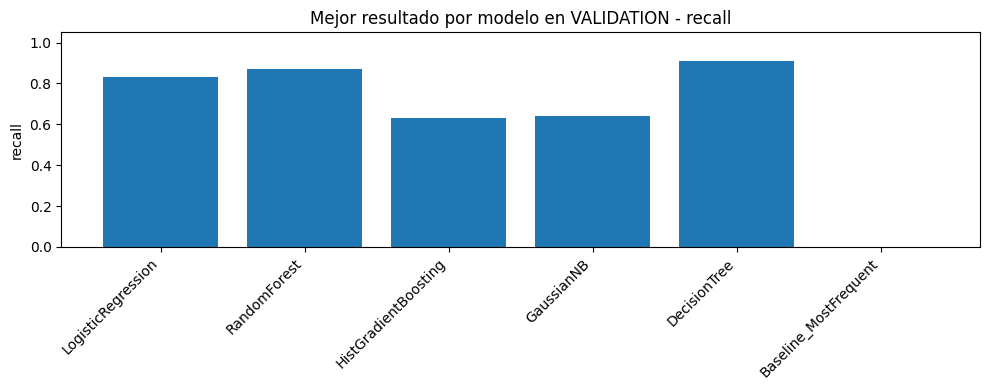

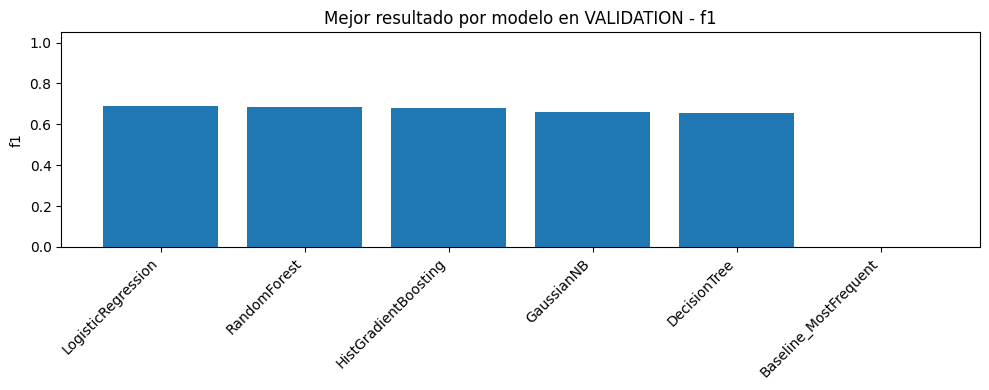

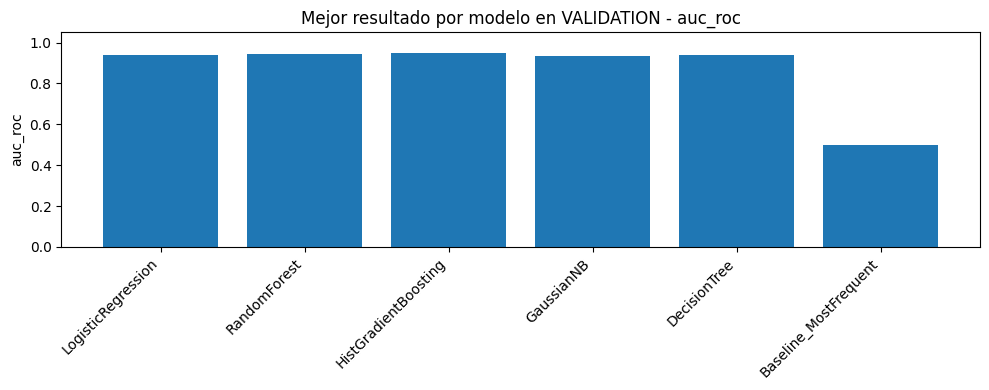

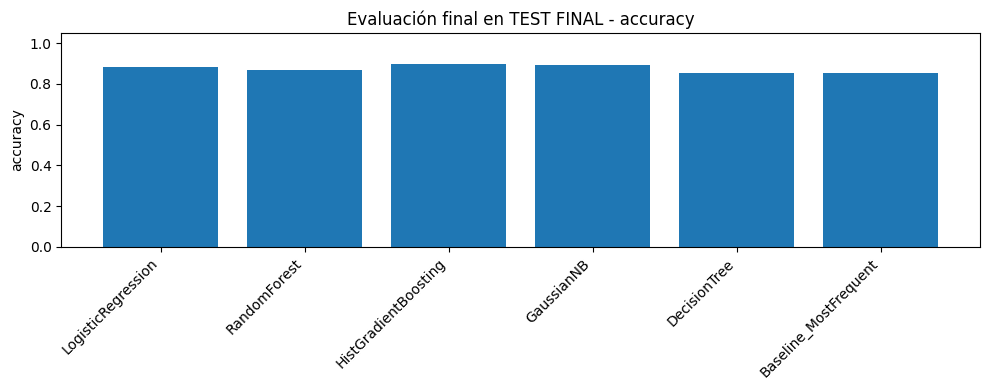

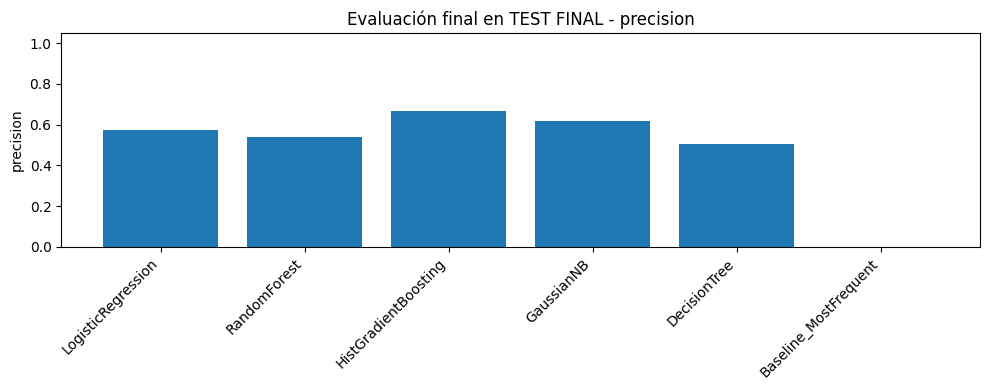

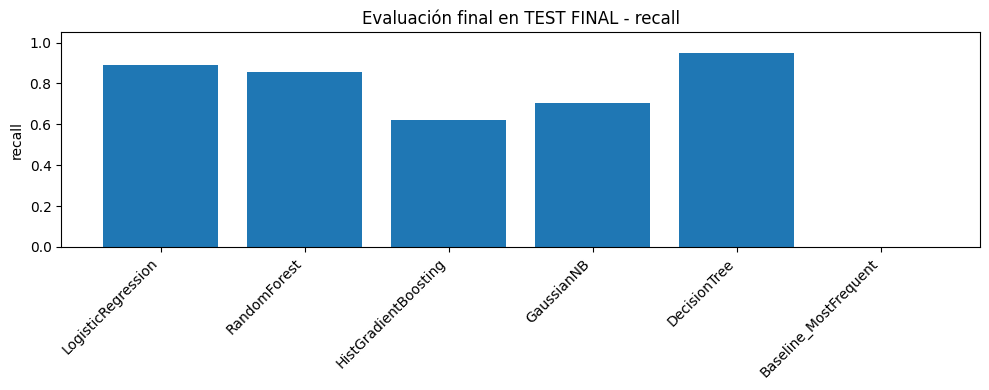

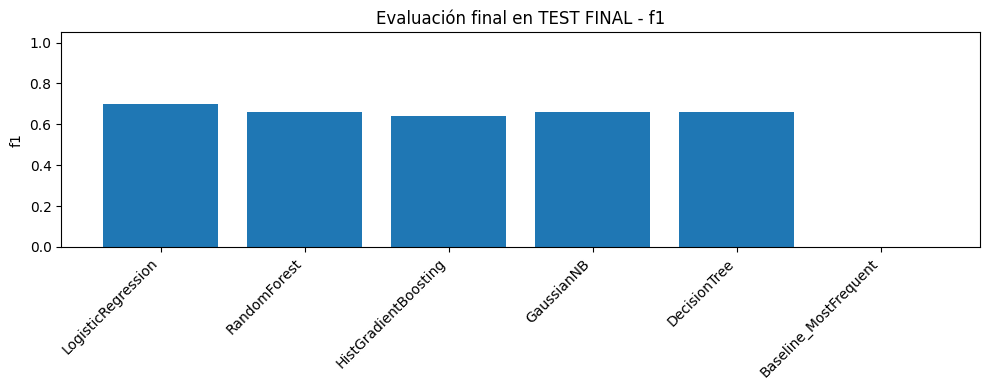

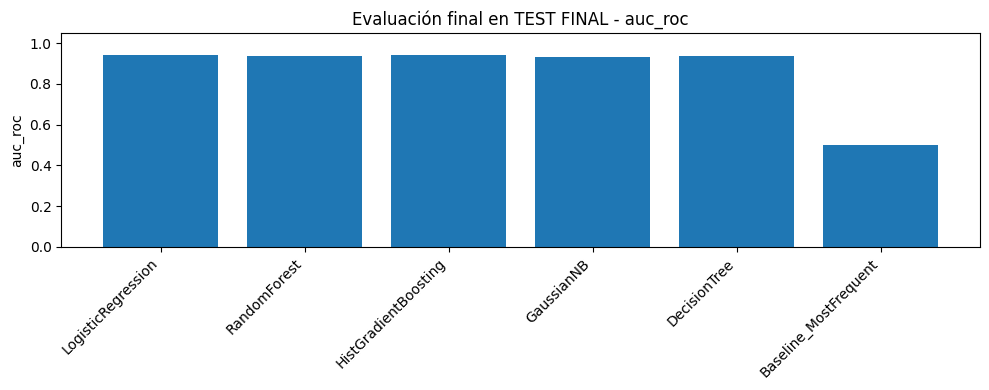

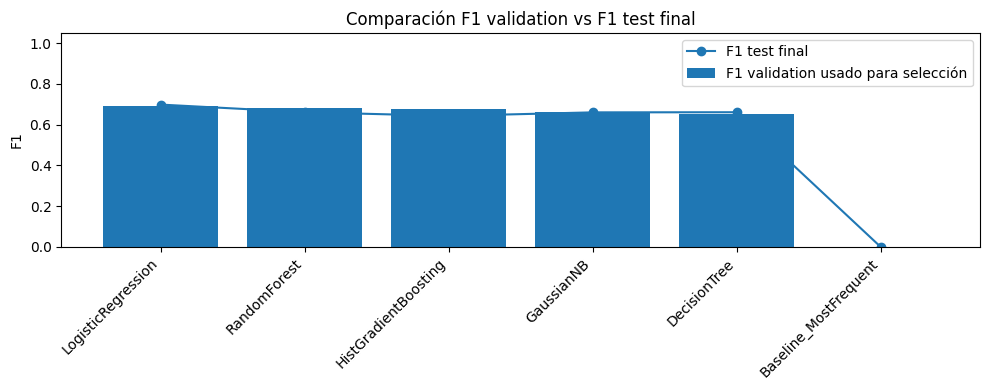

In [ ]:
# =========================
# 6.1 Comparativa visual de modelos: validation vs test final
# =========================

metrics_to_plot = ["accuracy", "precision", "recall", "f1", "auc_roc"]

validation_best = model_selection_results.copy()
test_final = results.copy()

for metric in metrics_to_plot:
    plt.figure(figsize=(10, 4))
    plt.bar(validation_best["model"], validation_best[metric])
    plt.title(f"Mejor resultado por modelo en VALIDATION - {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

for metric in metrics_to_plot:
    plt.figure(figsize=(10, 4))
    plt.bar(test_final["model"], test_final[metric])
    plt.title(f"Evaluación final en TEST FINAL - {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(10, 4))
plt.bar(test_final["model"], test_final["selected_validation_f1"], label="F1 validation usado para selección")
plt.plot(test_final["model"], test_final["f1"], marker="o", label="F1 test final")
plt.title("Comparación F1 validation vs F1 test final")
plt.ylabel("F1")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


Mejor modelo seleccionado usando VALIDATION, no test final:


,model,feature_set,split,accuracy,precision,recall,f1,auc_roc,candidate_id,params
0,LogisticRegression,sensorica_ambiental,validation,0.8841,0.5912,0.8321,0.6913,0.9397,8,"{'model__C': 10.0, 'model__class_weight': 'bal..."



Resultado de ese modelo en TEST FINAL:


,model,feature_set,split,accuracy,precision,recall,f1,auc_roc,selected_validation_f1,selected_validation_auc_roc,best_params
0,LogisticRegression,sensorica_ambiental,test_final,0.8848,0.5737,0.8911,0.6980,0.9397,0.6913,0.9397,"{'model__C': 10.0, 'model__class_weight': 'bal..."



Classification report sobre TEST FINAL:
              precision    recall  f1-score   support

           0     0.9788    0.8837    0.9288     54140
           1     0.5737    0.8911    0.6980      9508

    accuracy                         0.8848     63648
   macro avg     0.7763    0.8874    0.8134     63648
weighted avg     0.9183    0.8848    0.8944     63648



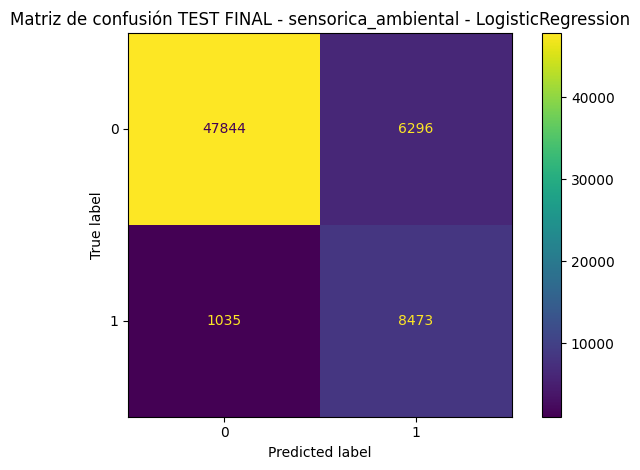

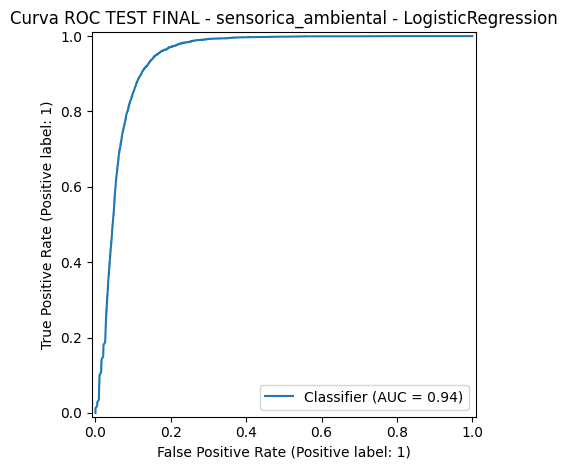

In [ ]:
# =========================
# 6.2 Mejor modelo seleccionado por validation y reporte en test final
# =========================

best_selection_row = model_selection_results.iloc[0]
best_feature_set = best_selection_row["feature_set"]
best_model_name = best_selection_row["model"]
best_features = SENSOR_FEATURES
best_model = fitted_models[best_model_name]

best_test_row = results.loc[results["model"] == best_model_name].iloc[0]

X_test_best = test_df[best_features]
y_test = test_df[TARGET]
y_pred_best = best_model.predict(X_test_best)
y_score_best = get_positive_scores(best_model, X_test_best)

print("Mejor modelo seleccionado usando VALIDATION, no test final:")
display(best_selection_row.to_frame().T)

print("\nResultado de ese modelo en TEST FINAL:")
display(best_test_row.to_frame().T)

print("\nClassification report sobre TEST FINAL:")
print(classification_report(y_test, y_pred_best, digits=4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.title(f"Matriz de confusión TEST FINAL - {best_feature_set} - {best_model_name}")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, y_score_best)
plt.title(f"Curva ROC TEST FINAL - {best_feature_set} - {best_model_name}")
plt.tight_layout()
plt.show()


## 7. Interpretabilidad: importancia de variables ambientales

La interpretación se centra únicamente en las variables ambientales.

Si `IndoorCO2` e `IndoorNoise` aparecen como relevantes, la explicación es  coherente: la presencia humana suele elevar CO₂ y ruido. Temperatura y humedad también pueden variar por ocupación, ventilación y climatización, aunque normalmente son señales más lentas.

Importancia del mejor modelo con sensórica ambiental:


,feature,abs_coefficient
3,IndoorNoise,1.9693
2,IndoorCO2,0.3464
1,IndoorHumidity,0.0600
0,IndoorTemperature,0.0438


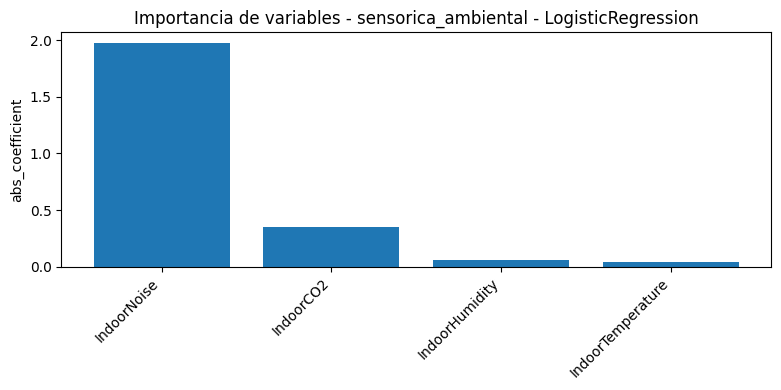

In [ ]:
# =========================
# 7. Importancia de variables
# =========================

def show_feature_importance(model, feature_names: list[str], title: str):
    final_model = model
    if isinstance(model, Pipeline):
        final_model = model.named_steps.get("model", model)

    importance = None
    label = "importance"

    if hasattr(final_model, "feature_importances_"):
        importance = final_model.feature_importances_
        label = "feature_importance"
    elif hasattr(final_model, "coef_"):
        importance = np.abs(final_model.coef_[0])
        label = "abs_coefficient"

    if importance is None:
        print(f"No hay importancia de variables directa para {title}")
        return None

    imp_df = pd.DataFrame({
        "feature": feature_names,
        label: importance,
    }).sort_values(label, ascending=False)

    display(imp_df)

    plt.figure(figsize=(8, 4))
    plt.bar(imp_df["feature"], imp_df[label])
    plt.title(title)
    plt.ylabel(label)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return imp_df

print("Importancia del mejor modelo con sensórica ambiental:")
best_importance = show_feature_importance(
    best_model,
    SENSOR_FEATURES,
    f"Importancia de variables - {best_feature_set} - {best_model_name}",
)

## 8. Guardado de artefactos en Drive

Se guardan todos los modelos probados dentro de `outputs_ingauge_engage_sensorica/models`.

El mejor modelo según F1 se guarda con prefijo `best_`.

Además se guardan:

- Resultados de evaluación.
- Índice de modelos generados.
- Dataset usable filtrado.
- Listado de variables utilizadas y variables excluidas.

In [ ]:
# =========================
# 8. Guardado de artefactos en Drive
# =========================

import joblib
from pathlib import Path

# Carpeta de modelos dentro del directorio de salida en Drive
MODELS_DIR = OUTPUT_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

required_objects = [
    "fitted_models",
    "best_model_name",
    "results",
    "model_selection_results",
    "tuning_results",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]
if missing_objects:
    raise NameError(
        "Faltan objetos necesarios para guardar artefactos. "
        f"Objetos faltantes: {missing_objects}"
    )

metrics_df = results.copy()
selection_df = model_selection_results.copy()
tuning_df = tuning_results.copy()

# Guardar todos los modelos finales reentrenados con train + validation.
# El mejor según validation lleva prefijo best_.
saved_models = []

for model_name, model in fitted_models.items():
    is_best = model_name == best_model_name
    prefix = "best_" if is_best else ""

    test_metrics = metrics_df.loc[
        metrics_df["model"] == model_name
    ].to_dict(orient="records")

    validation_metrics = selection_df.loc[
        selection_df["model"] == model_name
    ].to_dict(orient="records")

    test_metrics = test_metrics[0] if len(test_metrics) > 0 else {}
    validation_metrics = validation_metrics[0] if len(validation_metrics) > 0 else {}

    artifact = {
        "model": model,
        "model_name": model_name,
        "feature_set": "sensorica_ambiental",
        "features": SENSOR_FEATURES,
        "target": TARGET,
        "is_best": is_best,
        "split_strategy": {
            "type": "temporal_by_classroom",
            "train": "primer 60% temporal por aula",
            "validation": "siguiente 20% temporal por aula",
            "test_final": "último 20% temporal por aula",
            "model_selection": "validation",
            "final_evaluation": "test_final",
        },
        "validation_metrics": validation_metrics,
        "test_final_metrics": test_metrics,
        "best_params": test_metrics.get("best_params", {}),
        "excluded_context_features": [
            c for c in EXCLUDED_CONTEXT_FEATURES if c in df_usable.columns
        ],
        "justification": (
            "El modelo se entrena únicamente con variables procedentes de sensórica ambiental directa. "
            "Se excluyen variables de contexto docente, calendario, horario y operación HVAC para evitar "
            "que el modelo aprenda patrones administrativos o de planificación en lugar de inferir ocupación "
            "a partir de señales físicas medibles por sensores. "
            "La selección de modelo e hiperparámetros se realiza sobre validation temporal, "
            "dejando el test final como evaluación no usada para tomar decisiones de modelado."
        ),
    }

    model_filename = f"{prefix}sensorica_ambiental_{model_name}.joblib"
    model_path = MODELS_DIR / model_filename

    joblib.dump(artifact, model_path)

    saved_models.append({
        "model": model_name,
        "feature_set": "sensorica_ambiental",
        "is_best": is_best,
        "path": str(model_path),
        "selected_validation_f1": test_metrics.get("selected_validation_f1"),
        "test_final_f1": test_metrics.get("f1"),
        "test_final_auc_roc": test_metrics.get("auc_roc"),
        "best_params": test_metrics.get("best_params", {}),
    })

# Índice de modelos guardados
saved_models_df = pd.DataFrame(saved_models)
saved_models_path = OUTPUT_DIR / "saved_models_index_ingauge_occupancy_sensorica.csv"
saved_models_df.to_csv(saved_models_path, index=False)

# Resultados de evaluación final
results_path = OUTPUT_DIR / "model_results_ingauge_occupancy_sensorica_test_final.csv"
metrics_df.to_csv(results_path, index=False)

# Resultados de selección por validación
selection_path = OUTPUT_DIR / "model_selection_ingauge_occupancy_sensorica_validation.csv"
selection_df.to_csv(selection_path, index=False)

# Todas las combinaciones probadas
tuning_path = OUTPUT_DIR / "hyperparameter_tuning_ingauge_occupancy_sensorica_validation.csv"
tuning_df.to_csv(tuning_path, index=False)

# Resumen del split
split_summary_path = OUTPUT_DIR / "split_summary_train_validation_test.csv"
split_summary.to_csv(split_summary_path, index=False)

# Dataset usable
clean_data_path = OUTPUT_DIR / "ingauge_engage_usable_dataset_sensorica.csv"
df_usable.to_csv(clean_data_path, index=False)

# Auditoría de variables
excluded_existing_features = [
    c for c in EXCLUDED_CONTEXT_FEATURES if c in df_usable.columns
]

feature_audit = pd.DataFrame({
    "variable": SENSOR_FEATURES + excluded_existing_features,
    "status": (
        ["used_in_model"] * len(SENSOR_FEATURES)
        + ["excluded_from_model"] * len(excluded_existing_features)
    ),
    "reason": (
        ["Variable ambiental procedente de sensórica directa"] * len(SENSOR_FEATURES)
        + ["Variable de contexto, calendario, horario, operación o identificador"] * len(excluded_existing_features)
    )
})

feature_audit_path = OUTPUT_DIR / "feature_audit_sensorica_vs_contexto.csv"
feature_audit.to_csv(feature_audit_path, index=False)

print("Modelos guardados en:")
print(MODELS_DIR)

print("\nÍndice de modelos guardado en:")
print(saved_models_path)

print("\nResultados test final guardados en:")
print(results_path)

print("\nSelección por validation guardada en:")
print(selection_path)

print("\nHiperparametrización completa guardada en:")
print(tuning_path)

print("\nResumen de split guardado en:")
print(split_summary_path)

print("\nDataset usable guardado en:")
print(clean_data_path)

print("\nAuditoría de variables guardada en:")
print(feature_audit_path)

print("\nModelos generados:")
display(saved_models_df)

print("\nAuditoría de variables:")
display(feature_audit)


Modelos guardados en:
/content/drive/MyDrive/simarro-cursoia/caso-d-classrooms/outputs_ingauge_engage_sensorica/models

Índice de modelos guardado en:
/content/drive/MyDrive/simarro-cursoia/caso-d-classrooms/outputs_ingauge_engage_sensorica/saved_models_index_ingauge_occupancy_sensorica.csv

Resultados test final guardados en:
/content/drive/MyDrive/simarro-cursoia/caso-d-classrooms/outputs_ingauge_engage_sensorica/model_results_ingauge_occupancy_sensorica_test_final.csv

Selección por validation guardada en:
/content/drive/MyDrive/simarro-cursoia/caso-d-classrooms/outputs_ingauge_engage_sensorica/model_selection_ingauge_occupancy_sensorica_validation.csv

Hiperparametrización completa guardada en:
/content/drive/MyDrive/simarro-cursoia/caso-d-classrooms/outputs_ingauge_engage_sensorica/hyperparameter_tuning_ingauge_occupancy_sensorica_validation.csv

Resumen de split guardado en:
/content/drive/MyDrive/simarro-cursoia/caso-d-classrooms/outputs_ingauge_engage_sensorica/split_summary_tr

,model,feature_set,is_best,path,selected_validation_f1,test_final_f1,test_final_auc_roc,best_params
0,LogisticRegression,sensorica_ambiental,True,/content/drive/MyDrive/simarro-cursoia/caso-d-...,0.6913,0.6980,0.9397,"{'model__C': 10.0, 'model__class_weight': 'bal..."
1,RandomForest,sensorica_ambiental,False,/content/drive/MyDrive/simarro-cursoia/caso-d-...,0.6833,0.6606,0.9362,"{'model__max_depth': None, 'model__min_samples..."
2,HistGradientBoosting,sensorica_ambiental,False,/content/drive/MyDrive/simarro-cursoia/caso-d-...,0.6774,0.6425,0.9410,"{'model__l2_regularization': 0.0, 'model__lear..."
3,GaussianNB,sensorica_ambiental,False,/content/drive/MyDrive/simarro-cursoia/caso-d-...,0.6624,0.6599,0.9338,{'model__var_smoothing': 1e-09}
4,DecisionTree,sensorica_ambiental,False,/content/drive/MyDrive/simarro-cursoia/caso-d-...,0.6528,0.6605,0.9383,"{'model__max_depth': 4, 'model__min_samples_le..."
5,Baseline_MostFrequent,sensorica_ambiental,False,/content/drive/MyDrive/simarro-cursoia/caso-d-...,0.0000,0.0000,0.5000,{}



Auditoría de variables:


,variable,status,reason
0,IndoorTemperature,used_in_model,Variable ambiental procedente de sensórica dir...
1,IndoorHumidity,used_in_model,Variable ambiental procedente de sensórica dir...
2,IndoorCO2,used_in_model,Variable ambiental procedente de sensórica dir...
3,IndoorNoise,used_in_model,Variable ambiental procedente de sensórica dir...
4,Day,excluded_from_model,"Variable de contexto, calendario, horario, ope..."
5,Hour,excluded_from_model,"Variable de contexto, calendario, horario, ope..."
6,relative_weekday,excluded_from_model,"Variable de contexto, calendario, horario, ope..."
7,SchoolDay,excluded_from_model,"Variable de contexto, calendario, horario, ope..."
8,LessonNumber,excluded_from_model,"Variable de contexto, calendario, horario, ope..."
9,LessonPct,excluded_from_model,"Variable de contexto, calendario, horario, ope..."


9 - Metadata de modelos

In [22]:
# =========================
# 9. Metadata general de modelos
# =========================

import json
from pathlib import Path

# Asegurar que existen las variables esperadas
if "metrics_df" in globals():
    final_results_df = metrics_df.copy()
elif "test_results_df" in globals():
    final_results_df = test_results_df.copy()
elif "results_df" in globals():
    final_results_df = results_df.copy()
elif "results" in globals():
    final_results_df = results.copy()
else:
    raise NameError(
        "No se encontró el DataFrame de resultados finales. "
        "Se esperaba metrics_df, test_results_df, results_df o results."
    )

if "saved_models_df" not in globals():
    raise NameError(
        "No existe saved_models_df. Ejecutá primero la celda de guardado de modelos."
    )

if "best_model_name" not in globals():
    raise NameError(
        "No existe best_model_name. Revisar la celda de selección del mejor modelo."
    )

# Convertir rutas Path a string
output_dir_str = str(OUTPUT_DIR)
models_dir_str = str(MODELS_DIR)

# Si existen estos directorios, se agregan. Si no, se informan como None.
tables_dir_str = str(TABLES_DIR) if "TABLES_DIR" in globals() else None
figures_dir_str = str(FIGURES_DIR) if "FIGURES_DIR" in globals() else None

# Construir diccionario de modelos
models_metadata = {}

for _, row in saved_models_df.iterrows():
    model_name = row["model"]

    models_metadata[model_name] = {
        "path": row["path"],
        "is_best": bool(row["is_best"]),
        "feature_set": row.get("feature_set", "sensorica_ambiental"),
    }

# Ordenar ranking final por F1 si existe
ranking_df = final_results_df.copy()

if "f1" in ranking_df.columns:
    ranking_df = ranking_df.sort_values("f1", ascending=False)

# Convertir NaN a None para que el JSON sea válido
ranking_records = ranking_df.where(
    pd.notnull(ranking_df),
    None
).to_dict(orient="records")

# Metadata completa
models_metadata_json = {
    "case": "CASO D - CLASSROOM",
    "dataset": "In-Gauge and En-Gage classrooms",
    "problem_type": "binary_classification",
    "objective": (
        "Predicción de ocupación de aulas a partir de variables ambientales "
        "procedentes de sensórica, descartando variables de contexto docente, "
        "calendario, horario y operación."
    ),
    "best_model_name": best_model_name,
    "features": SENSOR_FEATURES,
    "target": TARGET,
    "feature_set": "sensorica_ambiental",
    "excluded_context_features": [
        c for c in EXCLUDED_CONTEXT_FEATURES if c in df_usable.columns
    ],
    "selection_metric": "f1 on validation",
    "final_evaluation": "test_final",
    "split_strategy": {
        "type": "temporal_by_classroom",
        "train": "first 60% of days per classroom",
        "validation": "next 20% of days per classroom",
        "test_final": "last 20% of days per classroom",
        "reason": (
            "Se usa split temporal por aula para evitar fuga de información temporal. "
            "La validación se usa para seleccionar modelo e hiperparámetros. "
            "El test final queda reservado para evaluación honesta."
        ),
    },
    "output_dir": output_dir_str,
    "tables_dir": tables_dir_str,
    "figures_dir": figures_dir_str,
    "models_dir": models_dir_str,
    "models": models_metadata,
    "ranking_test_final": ranking_records,
    "notes": {
        "why_context_features_are_excluded": (
            "Variables como Day, Hour, SchoolDay, LessonNumber o LessonPct pueden ser "
            "predictivas porque codifican calendario y planificación docente. Sin embargo, "
            "se excluyen porque el objetivo del caso es inferir ocupación desde señales "
            "físicas medibles por sensores, no desde información administrativa."
        ),
        "sensor_features_used": (
            "El modelo utiliza únicamente IndoorTemperature, IndoorHumidity, IndoorCO2 "
            "e IndoorNoise como aproximación a un escenario basado en sensórica ambiental."
        ),
    },
}

# Guardar JSON en Drive
metadata_path = OUTPUT_DIR / "models_metadata.json"

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(models_metadata_json, f, indent=2, ensure_ascii=False)

print("Metadata de modelos guardada en:")
print(metadata_path)

print("\nResumen metadata:")
print(json.dumps(models_metadata_json, indent=2, ensure_ascii=False))

Metadata de modelos guardada en:
/content/drive/MyDrive/simarro-cursoia/caso-d-classrooms/outputs_ingauge_engage_sensorica/models_metadata.json

Resumen metadata:
{
  "case": "CASO D - CLASSROOM",
  "dataset": "In-Gauge and En-Gage classrooms",
  "problem_type": "binary_classification",
  "objective": "Predicción de ocupación de aulas a partir de variables ambientales procedentes de sensórica, descartando variables de contexto docente, calendario, horario y operación.",
  "best_model_name": "LogisticRegression",
  "features": [
    "IndoorTemperature",
    "IndoorHumidity",
    "IndoorCO2",
    "IndoorNoise"
  ],
  "target": "Occupied",
  "feature_set": "sensorica_ambiental",
  "excluded_context_features": [
    "Day",
    "Hour",
    "relative_weekday",
    "SchoolDay",
    "LessonNumber",
    "LessonPct",
    "CoolingState",
    "HeatingState",
    "Time",
    "classroom_id",
    "UsabilityMask"
  ],
  "selection_metric": "f1 on validation",
  "final_evaluation": "test_final",
  "spl

## 9. Conclusiones del caso de D-Aulas en Australia

El notebook implementa una estrategia más estricta de evaluación:
- El entrenamiento usa el primer 60% temporal de cada aula.
- La validación usa el siguiente 20% temporal de cada aula y sirve para seleccionar modelo e hiperparámetros.
- El test final usa el último 20% temporal de cada aula y queda reservado para medir rendimiento final.

Para todos los conjuntos train / test / split se utilizan mismas proporciones de datos de todas las aulas.

Además, el modelo mantiene el enfoque metodológico de usar únicamente variables de sensórica ambiental directa. Las variables de contexto docente/calendario se analizan en el EDA porque son predictivas, pero se excluyen del modelo para evitar que la solución dependa del horario escolar y no de señales físicas observables por sensores.